# 2.5 Visualizing Relationships Between Groups Lab Submission


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loan_data.csv")

## Choose 5 additional features
### (Quantitative)
- person_income
- credit_score
- loan_int_rate

### (Categorical)
- person_education
- loan_intent

## Age vs Loan Status

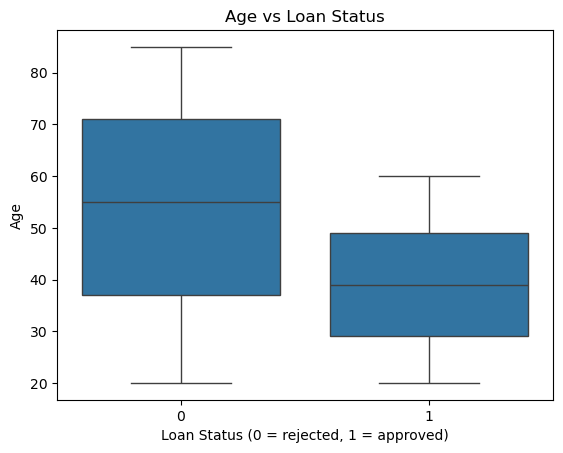

In [5]:
sns.boxplot(x="loan_status", y="person_age", data=df)
plt.title("Age vs Loan Status")
plt.xlabel("Loan Status (0 = rejected, 1 = approved)")
plt.ylabel("Age")
plt.show()


### Interpretation:
The boxplot shows that approved applicants (loan_status = 1) tend to be noticeably younger than the rejected applicants. The approved group has a lower median age and a much narrower age range, while the rejected group includes many older applicants and had a wider spread overall. This indicates that age is related to loan approval in this dataset, with younger applicants being approved more often.

## Income vs Loan Status

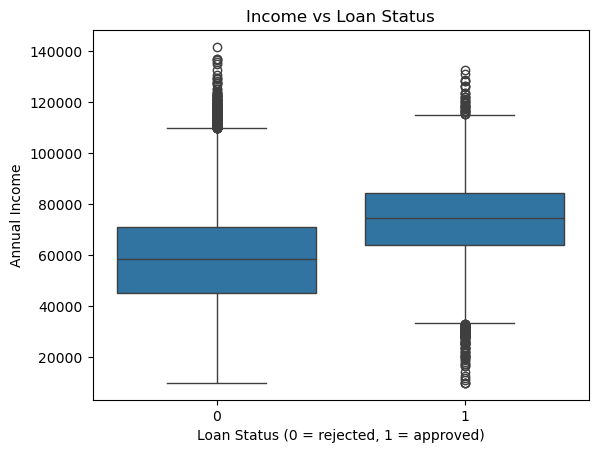

In [6]:
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Loan Status")
plt.xlabel("Loan Status (0 = rejected, 1 = approved)")
plt.ylabel("Annual Income")
plt.show()

### Interpretation:
The boxplot shows a clear upward shift in income for approved applicants compared to rejected ones. The approved group has a higher median income and the entire distribution is shifted upward, indicating that people with higher annual incomes are more likely to be approved. This suggests that imcome is a strong driver of loan approval in this dataset.

## Credit Score vs Loan Status

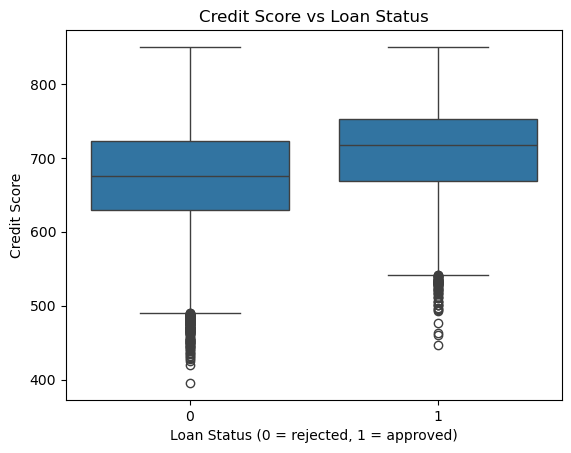

In [7]:
sns.boxplot(x="loan_status", y="credit_score", data=df)
plt.title("Credit Score vs Loan Status")
plt.xlabel("Loan Status (0 = rejected, 1 = approved)")
plt.ylabel("Credit Score")
plt.show()

### Interpretation:
The boxplot shows a strong separation between the two groups: approved applicants have substantially higher credit scores than rejected applicants. The median credit score for approved loans is clearly higher, and rejected applicants show many low-score outliers. This indicates that credit score is one of the strongest predictors of loan approval in the dataset.

## Loan Interest Rate vs Loan Status

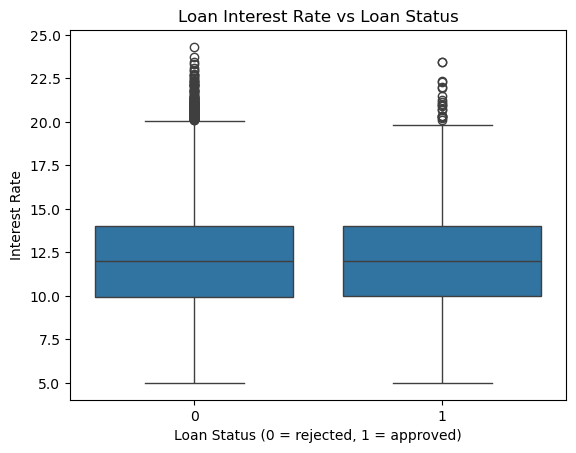

In [8]:
sns.boxplot(x="loan_status", y="loan_int_rate", data=df)
plt.title("Loan Interest Rate vs Loan Status")
plt.xlabel("Loan Status (0 = rejected, 1 = approved)")
plt.ylabel("Interest Rate")
plt.show()

### Interpretation:
The boxplot shows that interest rates are almost identical for approved and rejected applicants. The medians line up closely, the interquartile ranges overlap almost completely, and both groups share similar outliers. This indicates that loan interest rate does not meaningfully influence loan approval in this dataset.

## Gender vs Loan Status 

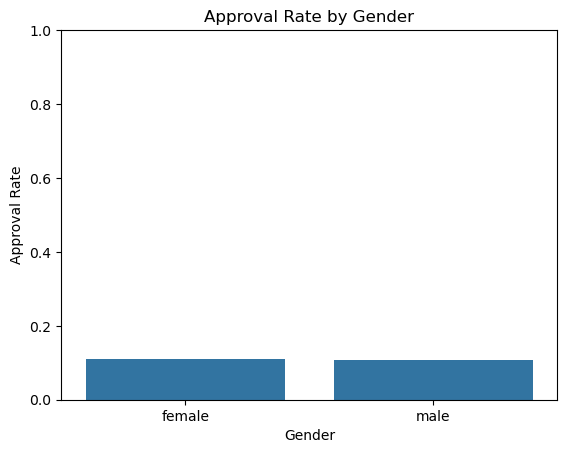

In [9]:
gender_rates = df.groupby("person_gender")["loan_status"].mean().reset_index()

sns.barplot(x="person_gender", y="loan_status", data=gender_rates)
plt.title("Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()

### Interpretation:
The bar chart shows that men and women have nearly identical loan approval rates. The bars are almost the same height, indicating no meaningful difference between genders in how often loans are approved. This suggests that gender does not appear to influence loan approval decisions in this datset.

## Education vs Loan Status

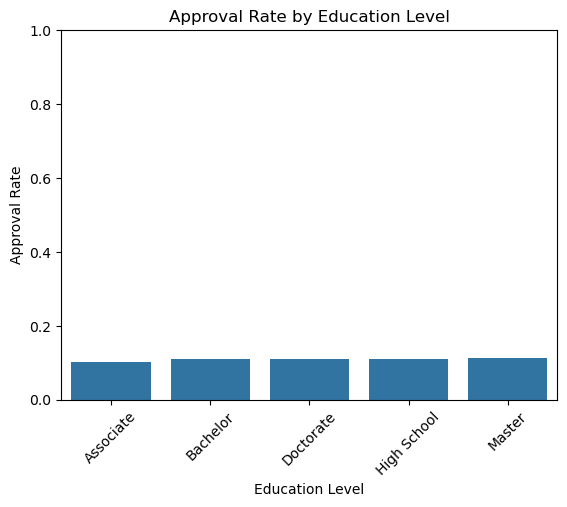

In [10]:
edu_rates = df.groupby("person_education")["loan_status"].mean().reset_index()

sns.barplot(x="person_education", y="loan_status", data=edu_rates)
plt.title("Approval Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

### Interpreation:
The bar chart shows that loan approval rates are nearly identical across all education levels. Each category has a bar of almost the same height, indicating no meaningful difference in approval likelihood. This suggests that education level does not play a significant role in the model's loan approval decisions.

## Loan Intent vs Loan Status

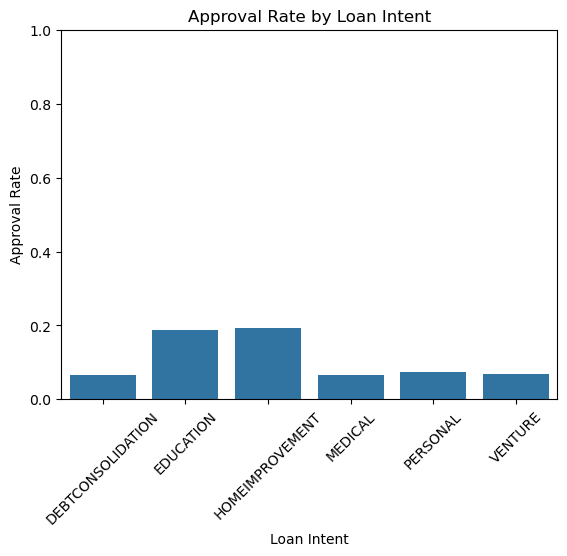

In [11]:
intent_rates = df.groupby("loan_intent")["loan_status"].mean().reset_index()

sns.barplot(x="loan_intent", y="loan_status", data=intent_rates)
plt.title("Approval Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The bar chart shows that approval rates vary noticeably across loan intents. Education and home-improvement loans have the highest approval rates, while categories like debt consolidation, medical, personal, and venture loans have much lower approval rates. This suggests that the purpose of the loan influences approval decisions, with some intents viewed as lower-risk or more favorable than others.

## Features that appear to drive loan approval
Based on the boxplots and bar charts, several features show clear separation between approved and rejected applicants:
### Credit Score
The credit score boxplot shows a strong difference between groups: aoproved applicants have substantially higher median credit scores, and rejected applicants show many low-score outliers. This is one of the strongest predictors of approval.
### Income
The income boxplot shows that approved applicants have higher median incomes and an upward-shifted distribution. Higher income clearly increases the likelihood of approval.
### Loan Intent
The bar chart shows that education and home-improvement loans have noticeably higher approval rates, while others like medical and personal loans have much lower rates. Loan purpose influences approval decisions.

These three features show the clearest relationship with loan_status

## Features that appear unrelated or weakly related
Based on the visualizations, I find these features are least likely to impact the outcome of the application:
### Interest Rate
The interest rate boxplot shows almost identical distributions for approved and rejected applicants. Interest rate does not appear to influence approval.
### Education Level
The education bar chart shows nearly identical approval rates across all education categories. Education is not a meaningful factor.
### Gender
The gender bar chart shows almost identical approval rates for men and women. Gender does not appear to influence approval.
### Age
The age boxplot shows that approved applicants tend to be younger, but the distributions overlap heavily. There is some relationship, but it is weaker than income or credit score.

## Should the financial institution be concerned about legal trouble?

The visualizations do not show strong evidence of direct discrimination based on age or sex. Gender appears unrelated to loan outcomes, as men and women have nearly identical approval rates. Age shows a slight pattern--approved applicants tend to be younger--but the distributions overlap heavily, suggesting that age is likely acting as a proxy for other financial factors rather than being used directly. However, the institution should still be cautious about potential indirect discrimination. Key drivers of approval, such as income, credit score, and loan intent, may correlate with protected characteristics in real-world populations, which can create disparate impact even when the model does not explicitly use age or sex. Overall, while that charts do not indicate illegal discrimination, the institution should continue documenting model behavior, monotoring for indirect bias, and ensuring compliances with fair-lending regulations.